✅ Librerías cargadas correctamente
✅ Datos SEP cargados: 2544 filas, 46 columnas
📌 Columnas INEGI detectadas: ['unnamed: 0', 'unnamed: 1', 'unnamed: 2', 'unnamed: 3', 'unnamed: 4', 'unnamed: 5', 'unnamed: 6', 'unnamed: 7', 'unnamed: 8', 'unnamed: 9']
✅ Datos INEGI cargados: 151 filas, 10 columnas
--- REPORTE DE CALIDAD DE DATOS ---

1. DATOS SEP:
Valores nulos por columna:
Unnamed: 0                    2544
SISTEMA EDUCATIVO NACIONAL       1
Unnamed: 2                       2
Unnamed: 3                       2
Unnamed: 4                     597
Unnamed: 5                     369
Unnamed: 6                     369
Unnamed: 7                     369
Unnamed: 8                     368
Unnamed: 9                     367
Unnamed: 10                    368
Unnamed: 11                    366
Unnamed: 12                    366
Unnamed: 13                    366
Unnamed: 14                    366
Unnamed: 15                    135
Unnamed: 16                    131
Unnamed: 17                  

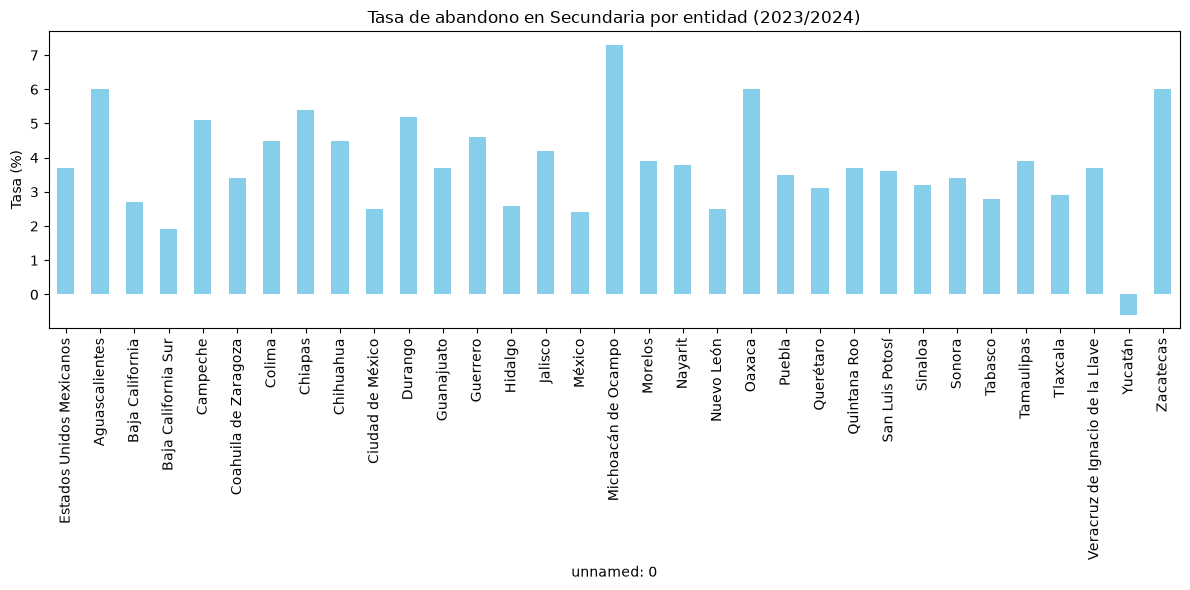


CONCLUSIONES DEL PERFIL DE DATOS (Sprint 1):
1. Los datos de SEP e INEGI se cargan correctamente (si existen en la ruta).
2. Se identificaron valores nulos y duplicados que deberán tratarse en el ETL (Sprint 3).
3. Las fuentes son oficiales y cubren el periodo requerido.
4. Son aptas para iniciar la construcción del Modelo Dimensional.



In [ ]:
# Celda 1: Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías bien")
# Aqui se cargan los datos de  sep 
try:
    df_sep = pd.read_excel("../data/raw/sep/serie_historica_entidades_sep.xlsm", engine="openpyxl")
    print(f"Datos SEP cargados: {df_sep.shape[0]} filas, {df_sep.shape[1]} columnas")
except Exception as e:
    print("No se pudo cargar SEP:", e)
    df_sep = pd.DataFrame()

# Aqui se cargan los datos de inegi 
try:
    df_inegi = pd.read_excel("../data/raw/inegi/Educacion_abandono.xlsx", header=2)
    df_inegi.columns = df_inegi.columns.str.strip().str.lower()
    print("Columnas INEGI detectadas:", df_inegi.columns.tolist())
    print(f"Datos INEGI cargados: {df_inegi.shape[0]} filas, {df_inegi.shape[1]} columnas")
except Exception as e:
    print("No se pudo cargar INEGI:", e)
    df_inegi = pd.DataFrame()

if not df_inegi.empty:
    plt.figure(figsize=(16, 10))

    # Detectar columnas clave con fallback seguro
    col_entidad = next((c for c in df_inegi.columns if "entidad" in c), df_inegi.columns[0])
    col_nivel   = next((c for c in df_inegi.columns if "nivel" in c), df_inegi.columns[1])
    col_anio    = next((c for c in df_inegi.columns if "2023/2024" in c), df_inegi.columns[-1])

    niveles = ["primaria", "secundaria", "media superior", "superior"]

    for i, nivel in enumerate(niveles, 1):
        plt.subplot(2, 2, i)  # 2 filas, 2 columnas de subplots
        df_plot = df_inegi[df_inegi[col_nivel].astype(str).str.lower() == nivel]
        df_plot.set_index(col_entidad)[col_anio].plot(kind="bar", color="skyblue")

        plt.title(f"Tasa de abandono en {nivel.capitalize()} (2023/2024)")
        plt.ylabel("Tasa (%)")
        plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

# Celda 4: Perfil de Calidad de Datos
print("--- REPORTE DE CALIDAD DE DATOS ---")
if not df_sep.empty:
    print("\n1. DATOS SEP:")
    print(f"Valores nulos por columna:\n{df_sep.isnull().sum()}")
    print(f"\nDuplicados en SEP: {df_sep.duplicated().sum()}")

if not df_inegi.empty:
    print("\n2. DATOS INEGI:")
    print(f"Valores nulos por columna:\n{df_inegi.isnull().sum()}")
    print(f"\nDuplicados en INEGI: {df_inegi.duplicated().sum()}")

# Celda 5: Visualización rápida
if not df_inegi.empty:
    plt.figure(figsize=(12, 6))

    # Buscar columnas clave con fallback seguro
    col_entidad = next((c for c in df_inegi.columns if "entidad" in c), df_inegi.columns[0])
    col_nivel   = next((c for c in df_inegi.columns if "nivel" in c), df_inegi.columns[1])
    col_anio    = next((c for c in df_inegi.columns if "2023/2024" in c), df_inegi.columns[-1])

    # Filtrar Secundaria y graficar
    if col_nivel in df_inegi.columns:
        df_plot = df_inegi[df_inegi[col_nivel].astype(str).str.lower() == "secundaria"]
        df_plot.set_index(col_entidad)[col_anio].plot(kind="bar", color="skyblue")

        plt.title("Tasa de abandono en Secundaria por entidad (2023/2024)")
        plt.ylabel("Tasa (%)")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
    else:
        print(" No se encontró columna de nivel educativo, se omitió la gráfica.")



# Celda 6: Conclusiones del Perfil
print("""
CONCLUSIONES DEL PERFIL DE DATOS (Sprint 1):
1. Los datos de SEP e INEGI se cargan correctamente (si existen en la ruta).
2. Se identificaron valores nulos y duplicados que deberán tratarse en el ETL (Sprint 3).
3. Las fuentes son oficiales y cubren el periodo requerido.
4. Son aptas para iniciar la construcción del Modelo Dimensional.
""")
